<a href="https://colab.research.google.com/github/aakankshaparate-git/iris-pro/blob/main/movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/IMDb Movies India.csv.zip", encoding='latin1')

In [ ]:
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [ ]:
df = df.dropna().copy()

In [ ]:
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,(2015),115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,(2001),153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [ ]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])

/tmp/ipykernel_2218/3071877352.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Genre'] = le.fit_transform(df['Genre'])
/tmp/ipykernel_2218/3071877352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Director'] = le.fit_transform(df['Director'])
/tmp/ipykernel_2218/3071877352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [ ]:
df['Genre']

,Genre
1,229
3,184
5,157
6,289
8,320
...,...
15493,229
15494,133
15503,28
15505,38


In [ ]:
X = df.drop(['Name', 'Rating'], axis=1)
y = df['Rating']

In [ ]:
X

,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
1,2019,109,229,8,629,1352,2272,Arvind Jangid
3,2019,110,184,35,1335,1198,719,Siddhant Kapoor
5,1997,147,157,827,1530,378,75,Shammi Kapoor
6,2005,142,289,1086,2044,692,1112,Yashpal Sharma
8,2012,82,320,326,135,1934,1175,Kiran Bhatia
...,...,...,...,...,...,...,...,...
15493,2015,115,229,408,1223,1861,1801,Raaghavv Chanana
15494,2001,153,133,1496,2059,763,1619,Manoj Bajpayee
15503,1989,125,28,44,1793,406,754,Rajinikanth
15505,1999,129,38,655,1025,112,2164,Aruna Irani


In [ ]:
y

,Rating
1,7.0
3,4.4
5,4.7
6,7.4
8,5.6
...,...
15493,6.1
15494,6.2
15503,5.8
15505,4.5


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

ValueError: could not convert string to float: 'Saanvi Dhiman'

In [ ]:
print(X_train.dtypes)

Year         int64
Duration     int64
Genre        int64
Votes        int64
Director     int64
Actor 1      int64
Actor 2      int64
Actor 3     object
dtype: object


In [ ]:
print(X_train.select_dtypes(include='object').columns)

Index(['Actor 3'], dtype='object')


In [ ]:
['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df[col]

,Actor 3
1,319
3,2148
5,2045
6,2524
8,1013
...,...
15493,1615
15494,1184
15503,1685
15505,314


In [ ]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [ ]:
X

,Name,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109,145,8,2020,394,1416,319
3,#Yaaram,2019,110,95,35,375,222,2010,2148
5,...Aur Pyaar Ho Gaya,1997,147,65,827,592,1270,2044,2045
6,...Yahaan,2005,142,211,1086,1163,1619,128,2524
8,?: A Question Mark,2012,82,247,326,391,1040,197,1013
...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,145,408,251,959,893,1615
15494,Zubeidaa,2001,153,39,1496,1179,1698,690,1184
15503,Zulm Ki Zanjeer,1989,125,201,44,883,1302,2049,1685
15505,Zulmi,1999,129,308,655,31,136,1296,314


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

ValueError: could not convert string to float: 'Mmirsa'

In [ ]:
X = df[['Year', 'Duration', 'Votes']]
y = df['Rating']

In [ ]:
X

,Year,Duration,Votes
1,2019,109,8
3,2019,110,35
5,1997,147,827
6,2005,142,1086
8,2012,82,326
...,...,...,...
15493,2015,115,408
15494,2001,153,1496
15503,1989,125,44
15505,1999,129,655


In [ ]:
print(X_train.select_dtypes(include=['object']).columns)

Index(['Name'], dtype='object')


In [ ]:
X_train.select_dtypes(include=['object']).head()

,Name
9424,Mmirsa
12009,Roti
4316,Eeshwar
6897,Junglee
2338,Bijuka


In [ ]:
X = df.drop(['Rating', 'Name'], axis=1)
y = df['Rating']

In [ ]:
X

,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
1,2019,109,145,8,2020,394,1416,319
3,2019,110,95,35,375,222,2010,2148
5,1997,147,65,827,592,1270,2044,2045
6,2005,142,211,1086,1163,1619,128,2524
8,2012,82,247,326,391,1040,197,1013
...,...,...,...,...,...,...,...,...
15493,2015,115,145,408,251,959,893,1615
15494,2001,153,39,1496,1179,1698,690,1184
15503,1989,125,201,44,883,1302,2049,1685
15505,1999,129,308,655,31,136,1296,314


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Name'] = le.fit_transform(df['Name'].astype(str))

In [ ]:
df['Name']

,Name
1,0
3,1
5,3
6,4
8,76
...,...
15493,5380
15494,5381
15503,5382
15505,5384


In [ ]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [ ]:
print(X_train.dtypes)

Year        int64
Duration    int64
Genre       int64
Votes       int64
Director    int64
Actor 1     int64
Actor 2     int64
Actor 3     int64
dtype: object


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
rf

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf

array([4.874, 5.932, 4.865, ..., 5.792, 5.686, 6.475])

In [ ]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [ ]:
evaluate_model(y_test, y_pred)

MAE: 1.0546494621528397
MSE: 1.7043897079488302
RMSE: 1.305522771899759
R2 Score: 0.07957577631774981


In [ ]:
evaluate_model(y_test, y_pred_rf)

MAE: 0.8486749116607774
MSE: 1.2478766872791516
RMSE: 1.1170840108421352
R2 Score: 0.32610721257971


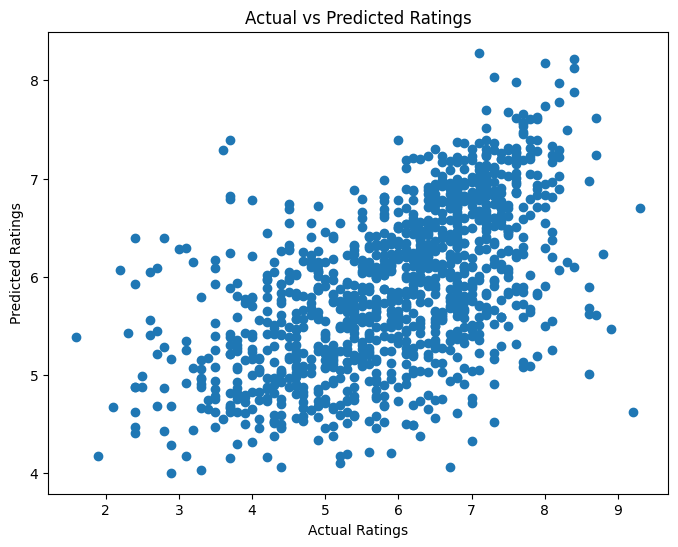

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

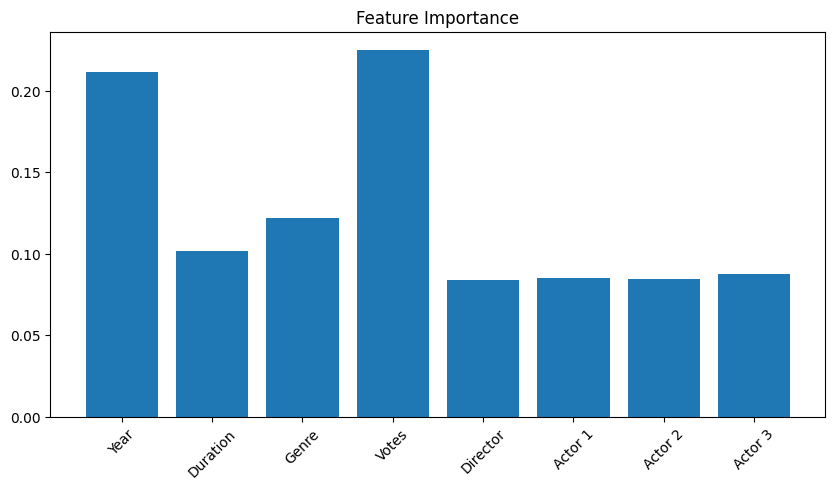

In [ ]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': y_pred_rf
})

print(results.head(10))

       Actual Rating  Predicted Rating
10971            6.0             4.874
14052            2.4             5.932
10002            3.8             4.865
3970             3.8             4.932
8840             7.2             5.819
5071             6.3             5.745
2709             8.6             5.009
11842            3.9             5.426
10910            6.6             5.566
4485             6.6             6.927
